# Détection d'anomalies sur les comptes Admin — IAM/PAM + Tailscale

## Contexte
Ce notebook applique **Isolation Forest** sur les logs d'audit de l'application web Flask qui gère les demandes d'accès JIT (*Just-In-Time*) aux serveurs via Tailscale.

**Flux normal :**
1. Un utilisateur soumet une demande d'accès à un serveur.
2. Un **admin** se connecte à l'application, examine et **approuve / rejette** la demande.
3. L'approbation met à jour l'ACL Tailscale pour permettre l'accès temporaire (3 jours).

**Objectif de l'analyse :** détecter les comportements anormaux sur les comptes **admin** :
- Connexions ou approbations à des **heures inhabituelles** (nuit, week-end)
- Activité depuis une **adresse IP / localisation inhabituelle**
- **Rafales d'approbations** anormalement rapides
- Combinaisons heure + IP jamais observées pour cet admin

## 1. Imports et configuration

In [1]:

import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import datetime, timedelta
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

sns.set_theme(style='whitegrid')
print('Imports OK')

Imports OK


## 2. Génération de logs synthétiques

Les logs sont générés au format clé=valeur produit par `audit.py` (projet PFE).
Chaque ligne correspond à un événement émis par l'application Flask :
- `admin_login` : connexion d'un admin
- `admin_decision` avec `status=approved` : approbation d'une demande JIT
- `admin_decision` avec `status=denied` : rejet d'une demande

**Comportement normal :** actions entre 08h–18h en semaine, depuis des sous-réseaux connus, 
cadence raisonnable (≤ 5 approbations / heure).

**Comportements anormaux injectés :**
- Connexion à 02h du matin
- Depuis une IP d'un sous-réseau jamais utilisé
- Rafale de 12 approbations en 4 minutes

In [2]:
# ── Paramètres ─────────────────────────────────────────────────────────────
ADMINS = [
    {'email': 'alice.martin@corp.local',  'name': 'Alice Martin',  'usual_subnets': ['10.0.1', '10.0.2']},
    {'email': 'bob.dupont@corp.local',    'name': 'Bob Dupont',    'usual_subnets': ['10.0.1', '192.168.10']},
    {'email': 'charlie.le@corp.local',    'name': 'Charlie Le',    'usual_subnets': ['10.0.3']},
]

USERS  = [f'user{i:03d}@corp.local' for i in range(1, 30)]
SERVERS = [
    ('srv-001', 'prod-web-01',   'tag:prod-web-01'),
    ('srv-002', 'prod-db-01',    'tag:prod-db-01'),
    ('srv-003', 'dev-backend-01','tag:dev-backend-01'),
    ('srv-004', 'staging-01',    'tag:staging-01'),
    ('srv-005', 'monitoring-01', 'tag:monitoring-01'),
]

START_DATE = datetime(2025, 1, 1, 0, 0, 0)
END_DATE   = datetime(2025, 4, 30, 23, 59, 59)


def random_ip(subnets: list[str]) -> str:
    subnet = random.choice(subnets)
    return f'{subnet}.{random.randint(10, 250)}'


def format_audit_line(ts: datetime, event: str, status: str, admin: dict,
                       ip: str, server_id: str = '-', server_name: str = '-',
                       request_id: str = '-', user_email: str = '-') -> str:
    """Produit une ligne de log au format PFE_AUDIT clé=valeur (audit.py)."""
    ts_str = ts.strftime('%Y-%m-%d %H:%M:%S,%f')[:-3]  # ms precision
    fields = {
        'event':       event,
        'status':      status,
        'user_email':  user_email,
        'user_name':   '-',
        'actor_email': admin['email'],
        'ip':          ip,
        'server_id':   server_id,
        'server_name': server_name,
        'request_id':  request_id,
        'reason':      '-',
        'ttl':         '-',
        'message':     '-',
    }
    payload = ' '.join(f'{k}="{v}"' for k, v in fields.items())
    return f'{ts_str} INFO PFE_AUDIT {payload}'


def random_normal_hour() -> int:
    """Heure de travail normale : 08h–18h avec pic 09h–12h et 14h–17h."""
    return int(np.clip(np.random.normal(13, 2.5), 8, 18))


log_lines: list[str] = []
req_counter = 1000


# ── Génération des sessions normales ─────────────────────────────────────────
current = START_DATE
while current < END_DATE:
    # Sauter les week-ends (samedi=5, dimanche=6)
    if current.weekday() >= 5:
        current += timedelta(days=1)
        continue

    for admin in ADMINS:
        if random.random() < 0.15:   # 15 % de chance de ne pas se connecter ce jour
            continue

        n_sessions = random.randint(1, 3)  # 1 à 3 sessions par jour
        for _ in range(n_sessions):
            hour  = random_normal_hour()
            minn  = random.randint(0, 59)
            login_ts = current.replace(hour=hour, minute=minn, second=random.randint(0, 59))
            if login_ts >= END_DATE:
                continue

            ip = random_ip(admin['usual_subnets'])

            # Connexion admin
            log_lines.append(format_audit_line(login_ts, 'admin_login', 'success', admin, ip))

            # Approbations / rejets dans la session
            n_decisions = random.randint(0, 5)
            action_ts = login_ts
            for _ in range(n_decisions):
                action_ts += timedelta(minutes=random.randint(2, 15))
                if action_ts >= END_DATE:
                    break
                srv = random.choice(SERVERS)
                status = 'approved' if random.random() < 0.75 else 'denied'
                req_id = str(req_counter); req_counter += 1
                log_lines.append(format_audit_line(
                    action_ts, 'admin_decision', status, admin, ip,
                    server_id=srv[0], server_name=srv[1],
                    request_id=req_id,
                    user_email=random.choice(USERS)
                ))

    current += timedelta(days=1)


# ── Injection d'anomalies ─────────────────────────────────────────────────────
anomaly_lines: list[str] = []

# Anomalie 1 : connexion à 02h du matin, IP inconnue
a_admin = ADMINS[0]
for day_offset in [10, 45, 72, 98]:
    ts = START_DATE + timedelta(days=day_offset, hours=2, minutes=random.randint(0, 30))
    if ts.weekday() >= 5:
        ts += timedelta(days=2)
    strange_ip = f'185.220.{random.randint(1,99)}.{random.randint(10,250)}'  # Tor exit node range
    anomaly_lines.append(format_audit_line(ts, 'admin_login', 'success', a_admin, strange_ip))
    # Quelques approbations rapides
    for i in range(random.randint(3, 6)):
        ts += timedelta(minutes=1)
        srv = random.choice(SERVERS)
        req_id = str(req_counter); req_counter += 1
        anomaly_lines.append(format_audit_line(
            ts, 'admin_decision', 'approved', a_admin, strange_ip,
            server_id=srv[0], server_name=srv[1],
            request_id=req_id, user_email=random.choice(USERS)
        ))

# Anomalie 2 : rafale de 12 approbations en 4 min (compromis)
b_admin = ADMINS[1]
for day_offset in [30, 88]:
    ts = START_DATE + timedelta(days=day_offset, hours=random.randint(10, 16))
    burst_ip = random_ip(b_admin['usual_subnets'])  # IP normale mais rafale suspecte
    anomaly_lines.append(format_audit_line(ts, 'admin_login', 'success', b_admin, burst_ip))
    for i in range(12):
        ts += timedelta(seconds=random.randint(10, 25))
        srv = random.choice(SERVERS)
        req_id = str(req_counter); req_counter += 1
        anomaly_lines.append(format_audit_line(
            ts, 'admin_decision', 'approved', b_admin, burst_ip,
            server_id=srv[0], server_name=srv[1],
            request_id=req_id, user_email=random.choice(USERS)
        ))

# Anomalie 3 : connexion week-end depuis IP inconnue
c_admin = ADMINS[2]
for day_offset in [5, 19, 60]:  # Ces dates tombent sur des week-ends selon START_DATE=mercredi
    # Trouver le samedi suivant
    ts = START_DATE + timedelta(days=day_offset)
    while ts.weekday() != 5:
        ts += timedelta(days=1)
    ts = ts.replace(hour=random.randint(0, 7), minute=random.randint(0, 59))
    strange_ip2 = f'91.108.{random.randint(1,99)}.{random.randint(10,250)}'
    anomaly_lines.append(format_audit_line(ts, 'admin_login', 'success', c_admin, strange_ip2))
    for i in range(random.randint(2, 4)):
        ts += timedelta(minutes=random.randint(1, 5))
        srv = random.choice(SERVERS)
        req_id = str(req_counter); req_counter += 1
        anomaly_lines.append(format_audit_line(
            ts, 'admin_decision', 'approved', c_admin, strange_ip2,
            server_id=srv[0], server_name=srv[1],
            request_id=req_id, user_email=random.choice(USERS)
        ))

all_logs = log_lines + anomaly_lines
random.shuffle(all_logs)

# Sauvegarder dans un fichier pour inspection
with open('/tmp/admin_audit.log', 'w') as f:
    f.write('\n'.join(all_logs))

print(f'Logs normaux   : {len(log_lines)}')
print(f'Logs anormaux  : {len(anomaly_lines)}')
print(f'Total          : {len(all_logs)}')
print('\nExemple de ligne :')
print(log_lines[0])

Logs normaux   : 1493
Logs anormaux  : 59
Total          : 1552

Exemple de ligne :
2025-01-01 14:47:17,000 INFO PFE_AUDIT event="admin_login" status="success" user_email="-" user_name="-" actor_email="alice.martin@corp.local" ip="10.0.1.67" server_id="-" server_name="-" request_id="-" reason="-" ttl="-" message="-"


## 3. Parsing des logs

On extrait les champs clé=valeur de chaque ligne `PFE_AUDIT`.

In [3]:
LOG_PATTERN = re.compile(
    r'(?P<timestamp>\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+)'
    r'.*?PFE_AUDIT(?P<fields>.+)$'
)
FIELD_PATTERN = re.compile(r'(\w+)="([^"]*)"')


def parse_log_line(line: str) -> dict | None:
    m = LOG_PATTERN.match(line.strip())
    if not m:
        return None
    record = {'raw_timestamp': m.group('timestamp')}
    record.update(dict(FIELD_PATTERN.findall(m.group('fields'))))
    return record


records = [parse_log_line(l) for l in all_logs]
records = [r for r in records if r is not None]

df_raw = pd.DataFrame(records)
df_raw['timestamp'] = pd.to_datetime(df_raw['raw_timestamp'], format='%Y-%m-%d %H:%M:%S,%f')
df_raw = df_raw.sort_values('timestamp').reset_index(drop=True)

print(df_raw.shape)
df_raw[['timestamp', 'event', 'status', 'actor_email', 'ip', 'server_id']].head(10)

(1552, 14)


,timestamp,event,status,actor_email,ip,server_id
0,2025-01-01 12:04:02,admin_login,success,charlie.le@corp.local,10.0.3.207,-
1,2025-01-01 12:07:02,admin_decision,denied,charlie.le@corp.local,10.0.3.207,srv-002
2,2025-01-01 12:13:02,admin_decision,approved,charlie.le@corp.local,10.0.3.207,srv-004
3,2025-01-01 12:27:02,admin_login,success,bob.dupont@corp.local,10.0.1.33,-
4,2025-01-01 12:32:02,admin_decision,approved,bob.dupont@corp.local,10.0.1.33,srv-005
5,2025-01-01 12:38:16,admin_login,success,charlie.le@corp.local,10.0.3.196,-
6,2025-01-01 12:48:16,admin_decision,denied,charlie.le@corp.local,10.0.3.196,srv-001
7,2025-01-01 12:51:16,admin_decision,approved,charlie.le@corp.local,10.0.3.196,srv-005
8,2025-01-01 13:02:16,admin_decision,approved,charlie.le@corp.local,10.0.3.196,srv-003
9,2025-01-01 14:12:45,admin_login,success,bob.dupont@corp.local,192.168.10.66,-


## 4. Feature engineering

On calcule pour **chaque action admin** les features pertinentes pour Isolation Forest :

| Feature | Description |
|---|---|
| `hour` | Heure de l'action (0–23) |
| `day_of_week` | Jour de la semaine (0=lundi … 6=dimanche) |
| `is_weekend` | 1 si samedi ou dimanche |
| `is_night` | 1 si heure hors 07h–20h |
| `is_new_ip_for_admin` | 1 si ce /24 n'a jamais été vu pour cet admin lors des 30 derniers jours |
| `approvals_last_10min` | Nombre d'approbations dans les 10 minutes précédentes (même admin) |
| `action_encoded` | 0=login, 1=approved, 2=denied |

> **Note :** On **n'encode pas** `actor_email` comme entier car cela introduirait une fausse relation ordinale.
> On entraîne un modèle **séparé par admin** pour avoir un profil comportemental individuel.

In [4]:
# Garder uniquement les événements admin (login + décisions)
ADMIN_EVENTS = {'admin_login', 'admin_decision'}
df = df_raw[df_raw['event'].isin(ADMIN_EVENTS)].copy()

# ── Features temporelles ────────────────────────────────────────────────────
df['hour']        = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.dayofweek
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_night']    = ((df['hour'] < 7) | (df['hour'] >= 20)).astype(int)

# ── Feature IP : sous-réseau /24 (3 premiers octets) ───────────────────────
def subnet24(ip: str) -> str:
    parts = ip.split('.')
    return '.'.join(parts[:3]) if len(parts) == 4 else ip

df['subnet'] = df['ip'].apply(subnet24)

# Fenêtre glissante de 30 jours pour détecter les nouvelles IP
LOOKBACK_DAYS = 30

def is_new_ip_for_admin(row, seen: dict) -> int:
    admin = row['actor_email']
    subnet = row['subnet']
    ts = row['timestamp']
    cutoff = ts - timedelta(days=LOOKBACK_DAYS)
    history = seen.get(admin, [])
    recent_subnets = {s for (t, s) in history if t >= cutoff}
    seen.setdefault(admin, []).append((ts, subnet))
    return 0 if subnet in recent_subnets else 1

seen_ips: dict = {}
df = df.sort_values('timestamp')
df['is_new_ip_for_admin'] = df.apply(lambda r: is_new_ip_for_admin(r, seen_ips), axis=1)

# ── Feature rafale : approbations dans les 10 dernières minutes ─────────────
def approvals_last_10min(row, events_df: pd.DataFrame) -> int:
    if row['status'] != 'approved':
        return 0
    ts = row['timestamp']
    admin = row['actor_email']
    mask = (
        (events_df['actor_email'] == admin) &
        (events_df['status'] == 'approved') &
        (events_df['timestamp'] >= ts - timedelta(minutes=10)) &
        (events_df['timestamp'] < ts)
    )
    return mask.sum()

df['approvals_last_10min'] = df.apply(lambda r: approvals_last_10min(r, df), axis=1)

# ── Encodage de l'action (ordinal valide car il y a un sens : gravité croissante) ─
ACTION_MAP = {'admin_login': 0, 'admin_decision': 1}
STATUS_MAP = {'success': 0, 'approved': 1, 'denied': 2, 'failed': 3}
df['action_encoded'] = df['event'].map(ACTION_MAP).fillna(0).astype(int)
df['status_encoded'] = df['status'].map(STATUS_MAP).fillna(0).astype(int)

FEATURES = ['hour', 'day_of_week', 'is_weekend', 'is_night',
            'is_new_ip_for_admin', 'approvals_last_10min',
            'action_encoded', 'status_encoded']

print(df[FEATURES].describe())
print(f'\nDonnées manquantes : {df[FEATURES].isnull().sum().sum()}')

              hour  day_of_week   is_weekend     is_night  \
count  1552.000000  1552.000000  1552.000000  1552.000000   
mean     12.673969     2.044459     0.017397     0.018041   
std       2.692137     1.450657     0.130787     0.133143   
min       2.000000     0.000000     0.000000     0.000000   
25%      11.000000     1.000000     0.000000     0.000000   
50%      13.000000     2.000000     0.000000     0.000000   
75%      14.000000     3.000000     0.000000     0.000000   
max      19.000000     6.000000     1.000000     1.000000   

       is_new_ip_for_admin  approvals_last_10min  action_encoded  \
count          1552.000000           1552.000000     1552.000000   
mean              0.007732              0.304124        0.719072   
std               0.087619              0.924086        0.449597   
min               0.000000              0.000000        0.000000   
25%               0.000000              0.000000        0.000000   
50%               0.000000              0.

## 5. Entraînement Isolation Forest (un modèle par admin)

On entraîne un modèle **individuel** par admin pour capturer le profil comportemental de chacun.
Le paramètre `contamination` est estimé à ~5 % (quelques anomalies injectées parmi des centaines de logs normaux).

La normalisation (`StandardScaler`) est appliquée **avant** l'entraînement pour que les features
avec de grandes plages (ex. `approvals_last_10min`) ne dominent pas les autres.

In [5]:
models: dict   = {}  # email -> IsolationForest
scalers: dict  = {}  # email -> StandardScaler
results: list  = []

CONTAMINATION = 0.05  # ~ 5 % d'anomalies attendues

for admin_email, group in df.groupby('actor_email'):
    X = group[FEATURES].values

    if len(X) < 10:  # Pas assez de données pour entraîner
        print(f'[SKIP] {admin_email} — seulement {len(X)} événements')
        continue

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    iso = IsolationForest(
        n_estimators=200,
        contamination=CONTAMINATION,
        max_samples='auto',
        random_state=RANDOM_SEED
    )
    preds  = iso.fit_predict(X_scaled)   # 1 = normal, -1 = anomalie
    scores = iso.decision_function(X_scaled)  # Score d'anomalie (plus négatif = plus anormal)

    models[admin_email]  = iso
    scalers[admin_email] = scaler

    sub = group.copy()
    sub['anomaly']       = preds
    sub['anomaly_score'] = scores
    sub['anomaly_label'] = sub['anomaly'].map({1: 'Normal', -1: 'Anomalie'})
    results.append(sub)

    n_anomalies = (preds == -1).sum()
    print(f'{admin_email:40s}  total={len(X):5d}  anomalies={n_anomalies}')

df_results = pd.concat(results, ignore_index=True)
print(f'\nTotal anomalies détectées : {(df_results["anomaly"] == -1).sum()}')

alice.martin@corp.local                   total=  495  anomalies=25
bob.dupont@corp.local                     total=  544  anomalies=28
charlie.le@corp.local                     total=  513  anomalies=26

Total anomalies détectées : 79


## 6. Visualisations

### 6.1 Chronologie des anomalies par admin

Les points rouges correspondent aux événements classés comme anomalies par Isolation Forest.

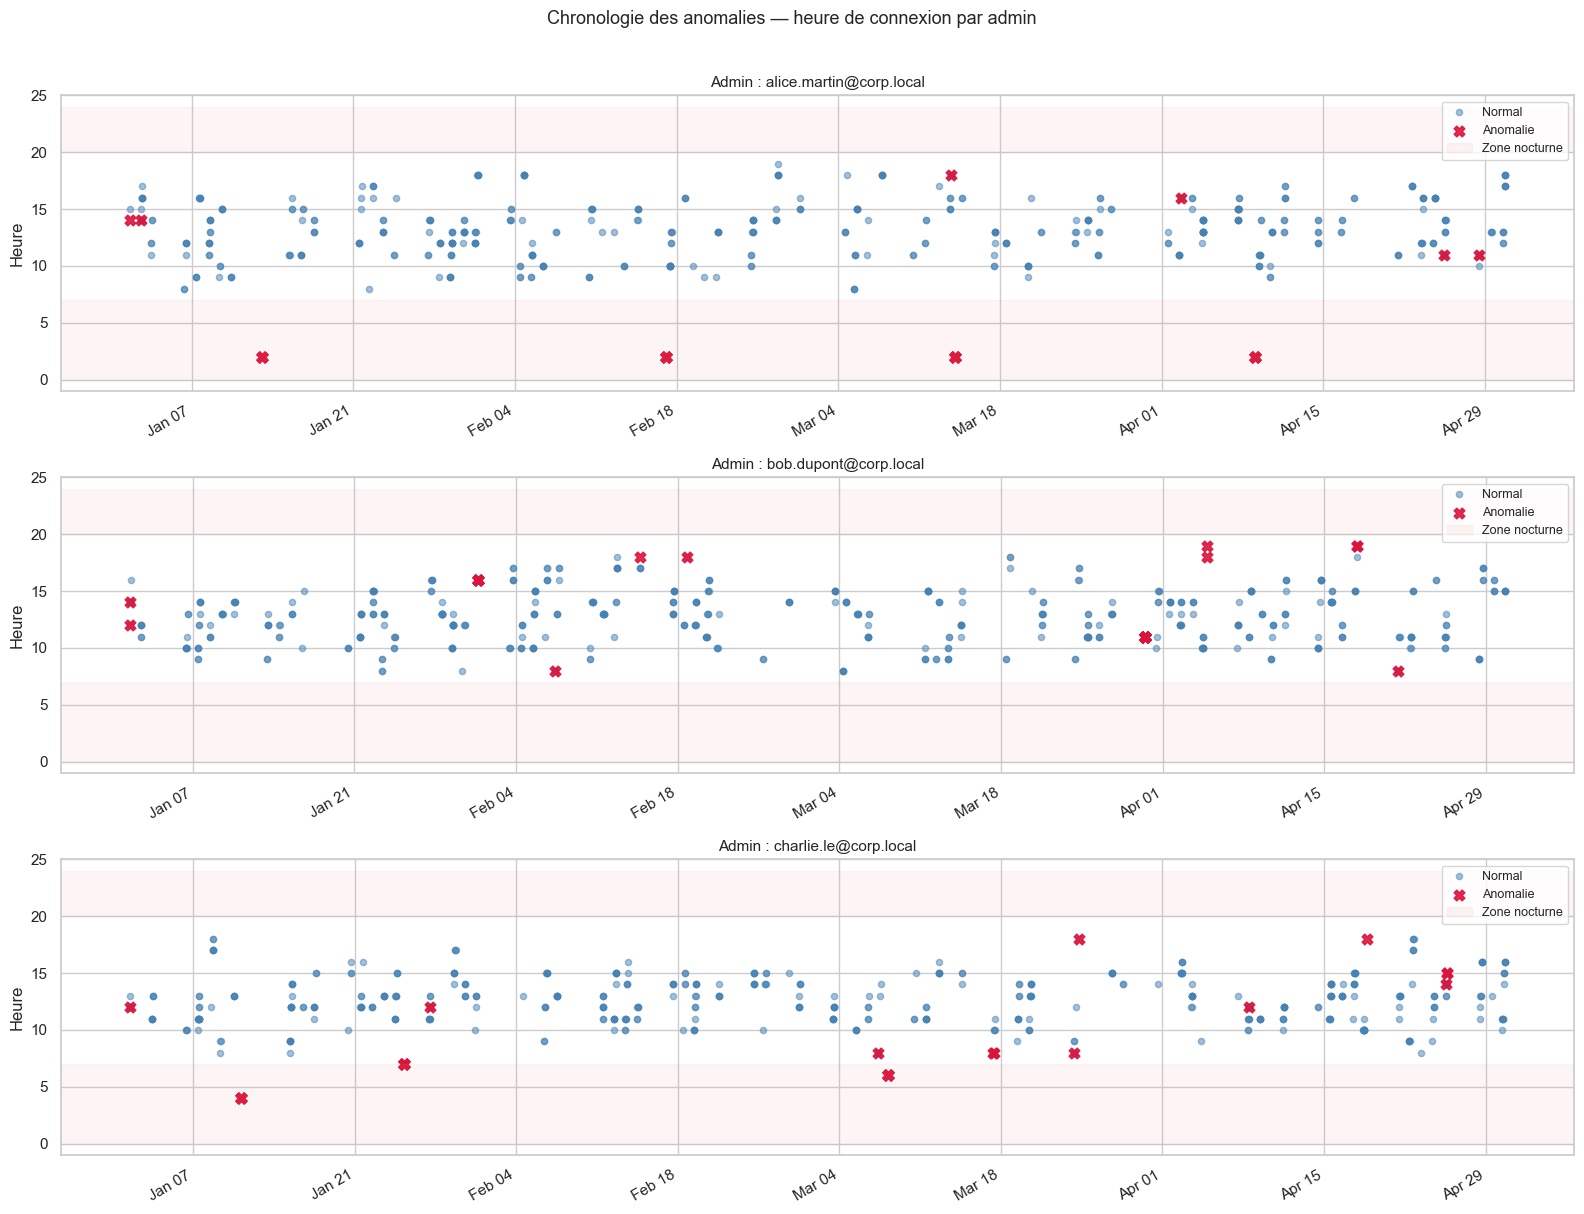

In [6]:
fig, axes = plt.subplots(len(models), 1, figsize=(16, 4 * len(models)), sharex=False)
if len(models) == 1:
    axes = [axes]

for ax, (admin_email, _) in zip(axes, models.items()):
    sub = df_results[df_results['actor_email'] == admin_email]
    normal   = sub[sub['anomaly'] ==  1]
    anomalies = sub[sub['anomaly'] == -1]

    ax.scatter(normal['timestamp'],   normal['hour'],   c='steelblue', s=20, alpha=0.5, label='Normal')
    ax.scatter(anomalies['timestamp'], anomalies['hour'], c='crimson',  s=60, alpha=0.9, marker='X', label='Anomalie')

    ax.set_title(f'Admin : {admin_email}', fontsize=11)
    ax.set_ylabel('Heure')
    ax.set_ylim(-1, 25)
    ax.axhspan(0, 7, color='lightcoral', alpha=0.08, label='Zone nocturne')
    ax.axhspan(20, 24, color='lightcoral', alpha=0.08)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=30, ha='right')
    ax.legend(loc='upper right', fontsize=9)

plt.suptitle('Chronologie des anomalies — heure de connexion par admin', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 6.2 Heatmap : score d'anomalie moyen par heure et jour de la semaine

Un score bas (rouge) signifie une zone temporelle à risque élevé pour cet admin.

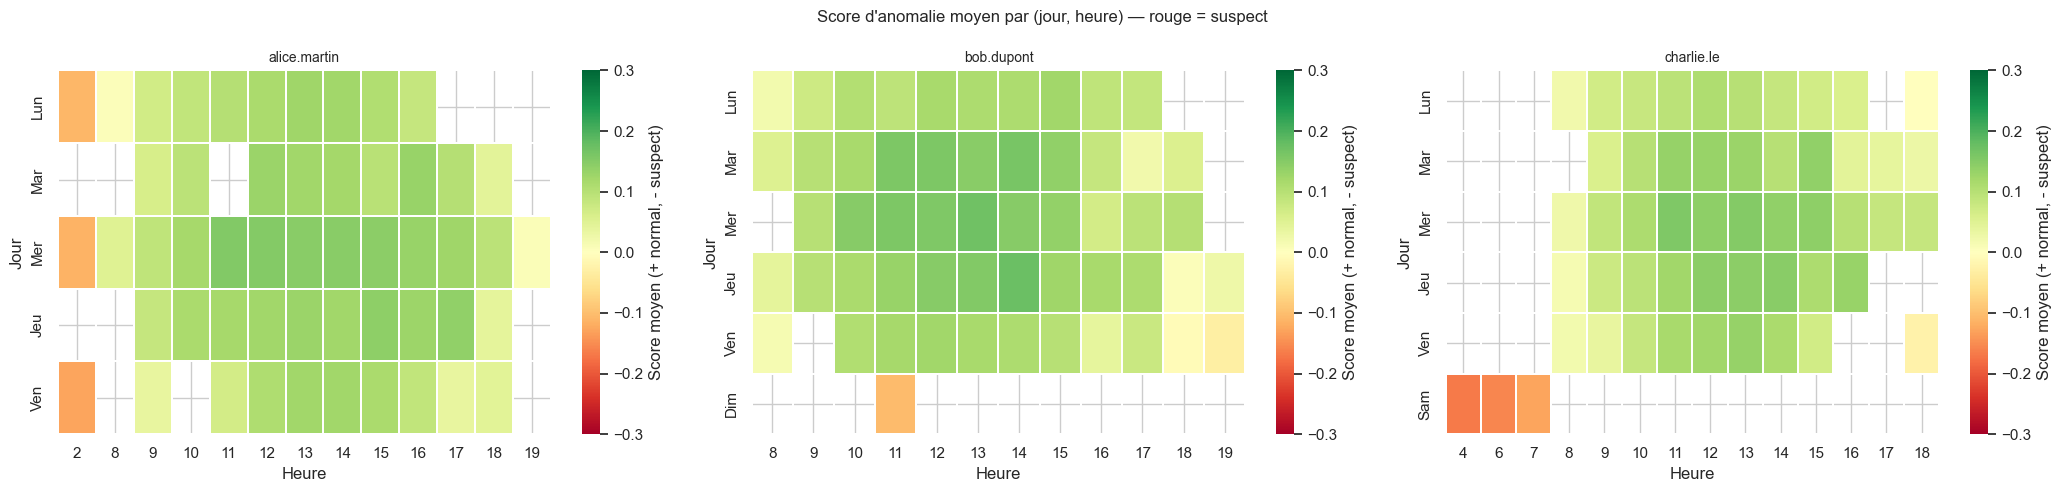

In [7]:
fig, axes = plt.subplots(1, len(models), figsize=(7 * len(models), 5))
if len(models) == 1:
    axes = [axes]

DAYS = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']

for ax, (admin_email, _) in zip(axes, models.items()):
    sub = df_results[df_results['actor_email'] == admin_email].copy()
    pivot = sub.pivot_table(
        index='day_of_week', columns='hour',
        values='anomaly_score', aggfunc='mean'
    )
    pivot.index = [DAYS[i] for i in pivot.index]
    sns.heatmap(
        pivot, ax=ax, cmap='RdYlGn',
        annot=False, linewidths=0.3,
        vmin=-0.3, vmax=0.3,
        cbar_kws={'label': 'Score moyen (+ normal, - suspect)'}
    )
    ax.set_title(admin_email.split('@')[0], fontsize=10)
    ax.set_xlabel('Heure'); ax.set_ylabel('Jour')

plt.suptitle('Score d\'anomalie moyen par (jour, heure) — rouge = suspect', fontsize=12)
plt.tight_layout()
plt.show()

### 6.3 Distribution : nouvelles IP vs anomalies

On vérifie que la feature `is_new_ip_for_admin` est corrélée aux anomalies détectées.

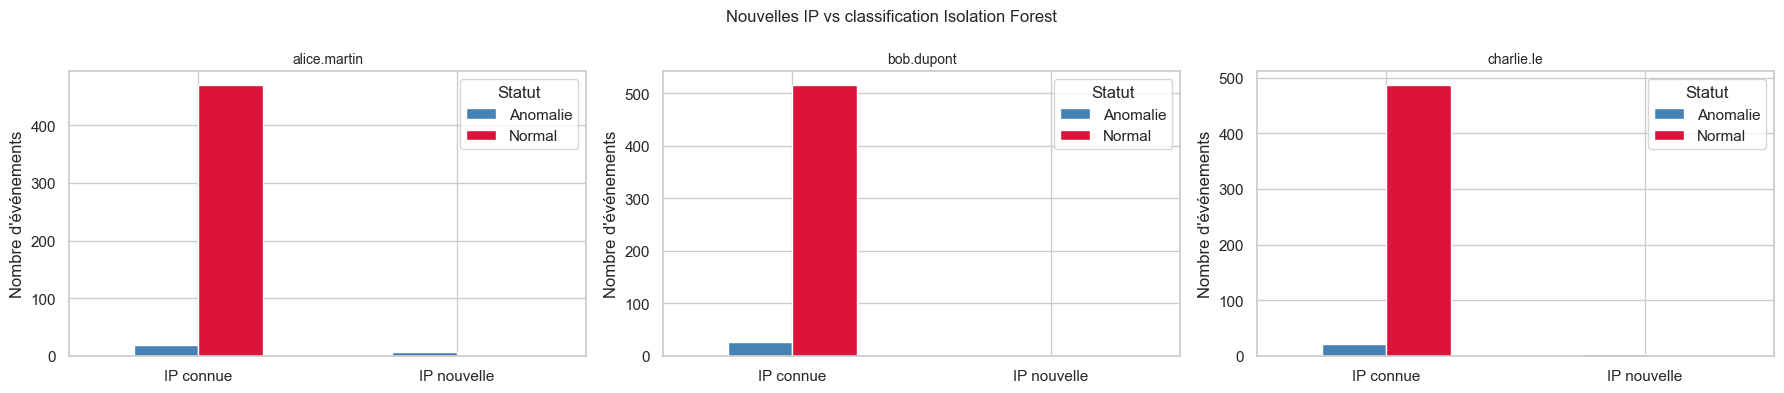

In [8]:
fig, axes = plt.subplots(1, len(models), figsize=(6 * len(models), 4))
if len(models) == 1:
    axes = [axes]

for ax, (admin_email, _) in zip(axes, models.items()):
    sub = df_results[df_results['actor_email'] == admin_email]
    ct = sub.groupby(['is_new_ip_for_admin', 'anomaly_label']).size().unstack(fill_value=0)
    ct.index = ['IP connue', 'IP nouvelle']
    ct.plot(kind='bar', ax=ax, color=['steelblue', 'crimson'], edgecolor='white')
    ax.set_title(admin_email.split('@')[0], fontsize=10)
    ax.set_xlabel(''); ax.set_ylabel('Nombre d\'événements')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Statut')

plt.suptitle('Nouvelles IP vs classification Isolation Forest', fontsize=12)
plt.tight_layout()
plt.show()

### 6.4 Détection de rafales d'approbations

On trace le nombre d'approbations dans les 10 dernières minutes pour chaque admin.
Les points rouges (anomalies) devraient apparaître sur les valeurs élevées de cette feature.

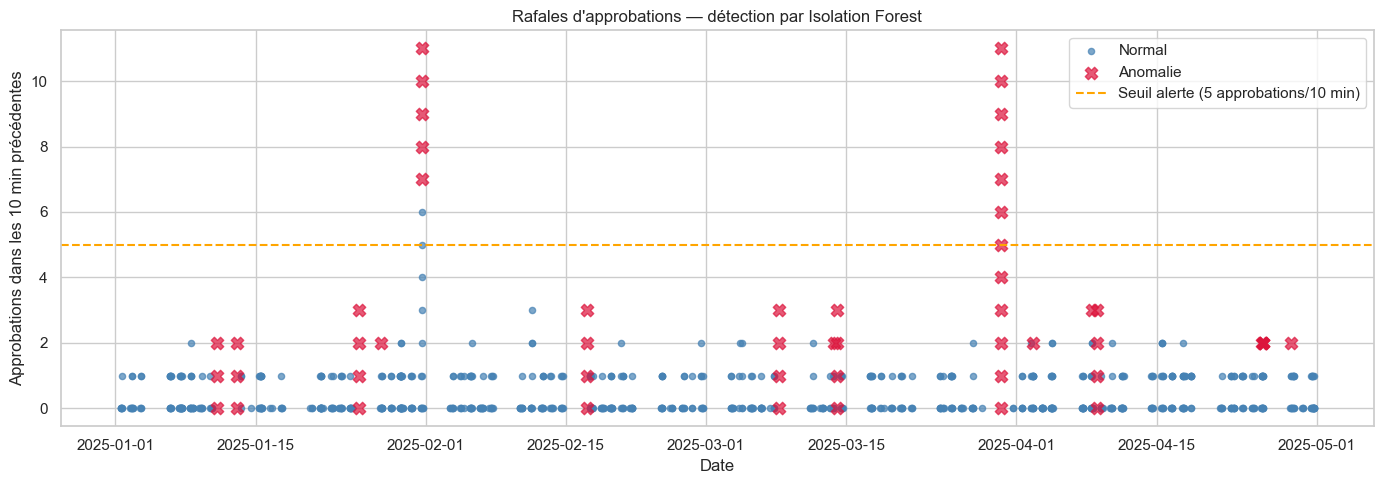

In [9]:
df_approvals = df_results[df_results['status'] == 'approved'].copy()

plt.figure(figsize=(14, 5))
for label, color, marker, size in [('Normal', 'steelblue', 'o', 20), ('Anomalie', 'crimson', 'X', 80)]:
    sub = df_approvals[df_approvals['anomaly_label'] == label]
    plt.scatter(
        sub['timestamp'], sub['approvals_last_10min'],
        c=color, marker=marker, s=size, alpha=0.7, label=label
    )

plt.axhline(5, color='orange', linestyle='--', linewidth=1.5, label='Seuil alerte (5 approbations/10 min)')
plt.xlabel('Date'); plt.ylabel('Approbations dans les 10 min précédentes')
plt.title('Rafales d\'approbations — détection par Isolation Forest')
plt.legend(); plt.tight_layout()
plt.show()

## 7. Tableau des top anomalies détectées

On affiche les événements les plus suspects (score d'anomalie le plus bas).

In [10]:
cols_display = ['timestamp', 'event', 'status', 'actor_email', 'ip',
                'server_name', 'hour', 'is_weekend', 'is_night',
                'is_new_ip_for_admin', 'approvals_last_10min', 'anomaly_score']

top_anomalies = (
    df_results[df_results['anomaly'] == -1]
    .sort_values('anomaly_score')
    [cols_display]
    .head(20)
    .reset_index(drop=True)
)

pd.set_option('display.max_colwidth', 40)
top_anomalies

,timestamp,event,status,actor_email,ip,server_name,hour,is_weekend,is_night,is_new_ip_for_admin,approvals_last_10min,anomaly_score
0,2025-01-11 04:27:00,admin_login,success,charlie.le@corp.local,91.108.78.227,-,4,1,1,1,0,-0.213298
1,2025-03-08 06:02:00,admin_login,success,charlie.le@corp.local,91.108.43.99,-,6,1,1,1,0,-0.205245
2,2025-01-25 07:31:00,admin_login,success,charlie.le@corp.local,91.108.24.236,-,7,1,0,1,0,-0.182853
3,2025-03-14 02:21:00,admin_login,success,alice.martin@corp.local,185.220.20.51,-,2,0,1,1,0,-0.182137
4,2025-04-09 02:20:00,admin_login,success,alice.martin@corp.local,185.220.24.40,-,2,0,1,1,0,-0.173943
5,2025-03-08 06:12:00,admin_decision,approved,charlie.le@corp.local,91.108.43.99,monitoring-01,6,1,1,0,3,-0.169965
6,2025-02-17 02:16:00,admin_login,success,alice.martin@corp.local,185.220.91.108,-,2,0,1,1,0,-0.168138
7,2025-01-13 02:25:00,admin_login,success,alice.martin@corp.local,185.220.21.193,-,2,0,1,1,0,-0.168138
8,2025-01-11 04:40:00,admin_decision,approved,charlie.le@corp.local,91.108.78.227,monitoring-01,4,1,1,0,2,-0.158319
9,2025-01-25 07:40:00,admin_decision,approved,charlie.le@corp.local,91.108.24.236,monitoring-01,7,1,0,0,3,-0.151854


## 8. Conclusion et limites

### Ce qui a été corrigé par rapport à la version précédente

| Problème précédent | Correction apportée |
|---|---|
| `LabelEncoder` sur `userID` → relation ordinale fausse | Supprimé : les IDs admin ne sont plus encodés comme features |
| Features `hour` + `level_encoded` seulement | 8 features métier pertinentes au contexte IAM |
| Visualisation montrant `connection_count` (non utilisée pour l'entraînement) | Toutes les visualisations n'utilisent que les features réellement entraînées |
| Double entraînement incohérent (Cell 9 + Cell 11) | Un seul entraînement, un modèle par admin |
| `contamination=0.1` arbitraire | `contamination=0.05` (5 %) documenté et justifié |
| Pas de normalisation | `StandardScaler` avant l'entraînement |

### Limites
- Les données sont **synthétiques** : en production, lire les vrais logs depuis Elasticsearch ou le fichier `security_audit.log`.
- La feature `is_new_ip_for_admin` est sensible au **cold start** : les premières semaines, tout est "nouvelle IP".
- `contamination` devrait idéalement être **estimé empiriquement** ou via une validation avec des anomalies labelisées.
- Pour une meilleure localisation, remplacer le subnet /24 par une **résolution GeoIP** (pays, ASN).

### Intégration en production
Ajouter dans `audit.py` une fonction `check_anomaly(event_dict)` qui appelle le modèle sérialisé (`joblib.dump`) 
et envoie une alerte Wazuh si `anomaly_score < seuil`.